# PCA：用主成分分析给数据降维

前面几篇文章处理的数据集特征维度都不高——房价 79 维、乳腺癌 30 维。当数据达到几百甚至几千维时，可视化困难、模型容易过拟合、计算开销大。PCA（Principal Component Analysis，主成分分析）是一种经典的**无监督降维**方法，它通过线性变换将原始高维数据映射到低维空间，同时尽可能保留数据的方差信息。

本文用 numpy 实现 PCA（基于 SVD），在手写数字数据集上演示降维效果。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA as SkPCA

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.pca import PCA

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

## 1. 数据集：手写数字

本文使用 **Digits 手写数字数据集**，包含 1797 个 8×8 的手写数字图像，每张图展开为 64 维向量，共 10 个类别（数字 0-9）。

64 维在 PCA 中属于低维数据，但拿来演示降维和可视化效果足够直观。

样本数量: 1797
特征维度: 64（8x8 灰度图展开）
类别数: 10（数字 0-9）


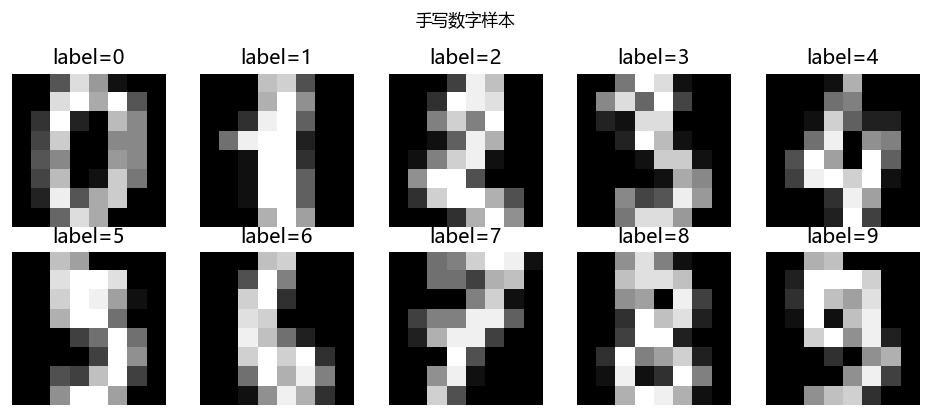

In [ ]:
digits = load_digits()
X, y = digits.data, digits.target
print(f'样本数量: {X.shape[0]}')
print(f'特征维度: {X.shape[1]}（8x8 灰度图展开）')
print(f'类别数: {len(np.unique(y))}（数字 0-9）')

# 展示前 10 张图
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'label={y[i]}')
    ax.axis('off')
plt.suptitle('手写数字样本', fontsize=10)
plt.tight_layout()
plt.show()

## 2. PCA 降维

用 PCA 将 64 维数据降到 2 维，保留方差最大的两个主成分。

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f'降维后: {X.shape[1]} 维 -> {X_pca.shape[1]} 维')
print(f'解释方差比: PC1={pca.explained_variance_ratio_[0]*100:.2f}%, '
      f'PC2={pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'累计解释方差: {pca.explained_variance_ratio_.sum()*100:.2f}%')

降维后: 64 维 -> 2 维
解释方差比: PC1=14.89%, PC2=13.62%
累计解释方差: 28.51%


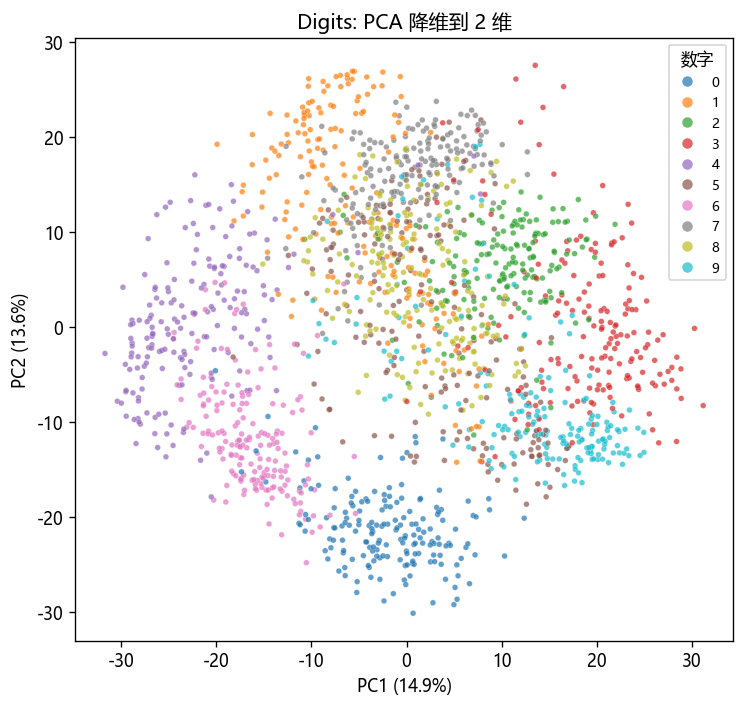

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10',
                     s=12, alpha=0.7, edgecolors='white', linewidth=0.2)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Digits: PCA 降维到 2 维')
legend = ax.legend(*scatter.legend_elements(), title='数字',
                   loc='upper right', fontsize=8)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 3. 解释方差：选多少个主成分？

PCA 的每个主成分都对应一个解释方差比，值越大表示该成分保留的信息越多。通常用**碎石图**（Scree Plot）观察方差随成分数的衰减趋势。

达到 90% 解释方差需要 21 个主成分
前 2 个主成分解释方差: 28.5%
前 10 个主成分解释方差: 73.8%
前 20 个主成分解释方差: 89.4%


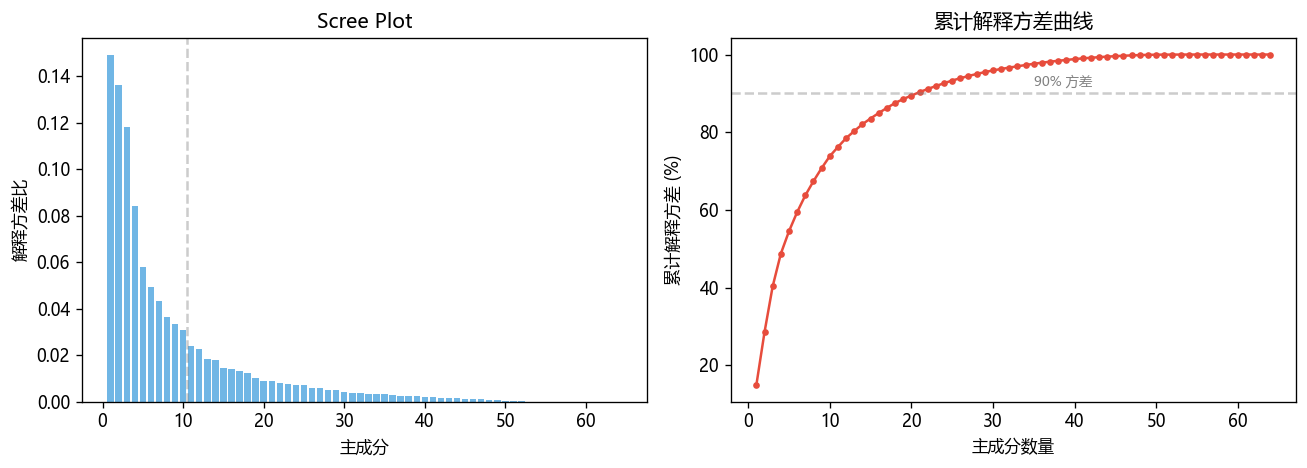

In [ ]:
pca_full = PCA()
pca_full.fit(X)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 单个方差比
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='#3498db', alpha=0.7, width=0.8)
axes[0].set_xlabel('主成分')
axes[0].set_ylabel('解释方差比')
axes[0].set_title('Scree Plot')
axes[0].axvline(x=10.5, color='gray', linestyle='--', alpha=0.4)

# 累计方差比
axes[1].plot(range(1, len(cumsum)+1), cumsum*100, 'o-', color='#e74c3c', markersize=3)
axes[1].axhline(y=90, color='gray', linestyle='--', alpha=0.4)
axes[1].set_xlabel('主成分数量')
axes[1].set_ylabel('累计解释方差 (%)')
axes[1].set_title('累计解释方差曲线')
axes[1].text(35, 92, '90% 方差', fontsize=8, color='gray')

# 达到 90% 所需的主成分数
n_90 = np.argmax(cumsum >= 0.90) + 1
print(f'达到 90% 解释方差需要 {n_90} 个主成分')
print(f'前 2 个主成分解释方差: {cumsum[1]*100:.1f}%')
print(f'前 10 个主成分解释方差: {cumsum[9]*100:.1f}%')
print(f'前 20 个主成分解释方差: {cumsum[19]*100:.1f}%')

plt.tight_layout()
plt.show()

## 4. 重建图像：不同维度 vs 压缩质量

降维是一种有损压缩。用 k 个主成分重建图像，观察不同 k 下的压缩质量。保留的主成分越多，重建越接近原图。

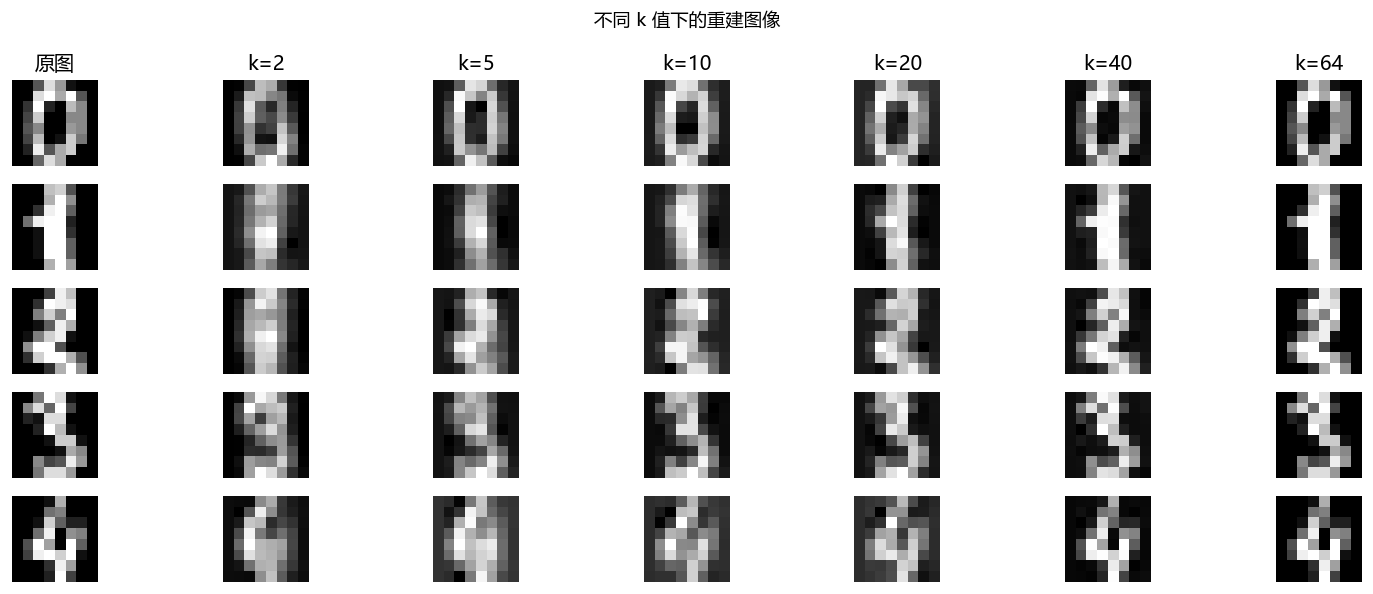

In [ ]:
n_components_list = [2, 5, 10, 20, 40, 64]
n_samples_show = 5

fig, axes = plt.subplots(n_samples_show, len(n_components_list)+1,
                         figsize=(13, 5))

for row in range(n_samples_show):
    # 原图
    axes[row, 0].imshow(digits.images[row], cmap='gray')
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_title('原图')

    for col, k in enumerate(n_components_list):
        pc = PCA(n_components=k)
        X_k = pc.fit_transform(X)
        X_recon = pc.inverse_transform(X_k)
        axes[row, col+1].imshow(X_recon[row].reshape(8, 8), cmap='gray')
        axes[row, col+1].axis('off')
        if row == 0:
            axes[row, col+1].set_title(f'k={k}')

plt.suptitle('不同 k 值下的重建图像', fontsize=11)
plt.tight_layout()
plt.show()

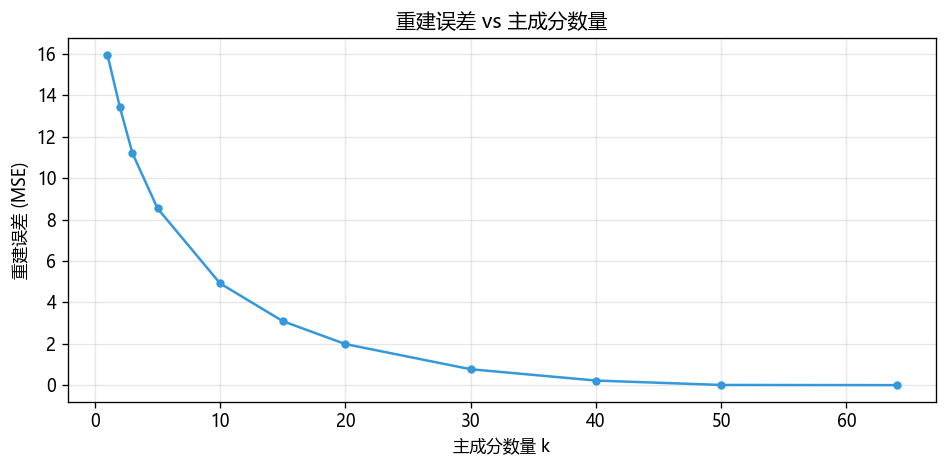

In [ ]:
ks = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 64]
errors = []
for k in ks:
    pc = PCA(n_components=k)
    X_k = pc.fit_transform(X)
    X_recon = pc.inverse_transform(X_k)
    mse = ((X - X_recon) ** 2).mean()
    errors.append(mse)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, errors, 'o-', color='#3498db', markersize=4)
ax.set_xlabel('主成分数量 k')
ax.set_ylabel('重建误差 (MSE)')
ax.set_title('重建误差 vs 主成分数量')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 与 sklearn 对比验证

相同数据上对比我们的 PCA 与 sklearn 的 PCA。

In [ ]:
pca_ours = PCA(n_components=10)
pca_sk = SkPCA(n_components=10)

X_ours = pca_ours.fit_transform(X)
X_sk = pca_sk.fit_transform(X)

# 比较解释方差比
ratio_diff = np.abs(pca_ours.explained_variance_ratio_ - pca_sk.explained_variance_ratio_)
print(f'解释方差比最大差异: {ratio_diff.max():.2e}')

# 比较投影结果（可能有符号翻转）
from scipy.stats import pearsonr
corrs = []
for i in range(10):
    r, _ = pearsonr(X_ours[:, i], X_sk[:, i])
    corrs.append(abs(r))
print(f'各主成分相关系数: {[f"{c:.4f}" for c in corrs]}')
print(f'平均相关系数: {np.mean(corrs):.4f}')

if np.mean(corrs) > 0.999:
    print('结果: 完全一致')
else:
    print('结果: 有微小差异（可能是符号翻转）')

解释方差比最大差异: 2.78e-16
各主成分相关系数: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
平均相关系数: 1.0000
结果: 完全一致


## 小结

- **PCA** 通过寻找方差最大的方向（主成分）来实现降维
- 基于 **SVD** 分解，不需要计算协方差矩阵的特征分解
- **解释方差比** 衡量每个主成分保留的信息量
- **碎石图** 和 **累计方差曲线** 辅助选择主成分数量
- 降维是一种有损压缩：k 越大重建越精确，但降维效果越小
- PCA 常用于可视化、去噪、数据预处理（减少特征数、缓解过拟合）